Chronos is a very powerful model for time series that outperforms
standard regression $(y(*, t_{\text{future}}) = f(y(*, t_{\text{now}})))$ on **short-term horizons** (<10–20 hours).
See: \url{https://github.com/amazon-science/chronos-forecasting}.

In our context, we do not use it because classical regression achieves equivalent error on middle-term horizons (1 to 7 days) while being faster to compute, but remind Chronos as a powerfull tool to predict the next hours



In [ ]:
#!pip install chronos-forecasting

In [ ]:
# ---------------------------------------------------------
# Imports
# ---------------------------------------------------------

import numpy as np
import xarray as xr
from chronos import Chronos2Pipeline
import torch

In [ ]:
# Load dataset
ds = xr.open_dataset("../full_db.nc")

In [ ]:
bike_0 = np.array((ds["vm_disp"] + ds["vae_disp"])).astype(float)

#Here you should put GPU if you have one. Cpu will take many minutes runtime vs few seconds with GPU

In [ ]:
device = "cpu" # ou "cpu"

In [ ]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)

In [ ]:
help(pipeline.predict)

Help on method predict in module chronos.chronos2.pipeline:

predict(inputs: Union[torch.Tensor, numpy.ndarray, Sequence[torch.Tensor | numpy.ndarray], Sequence[Mapping[str, Union[torch.Tensor, numpy.ndarray, Mapping[str, torch.Tensor | numpy.ndarray]]]]], prediction_length: int | None = None, batch_size: int = 256, context_length: int | None = None, cross_learning: bool = False, limit_prediction_length: bool = False, **kwargs) -> list[torch.Tensor] method of chronos.chronos2.pipeline.Chronos2Pipeline instance
    Generate forecasts for the given time series.

    Parameters
    ----------
    inputs
        The time series to generate forecasts for, can be one of:
        - A 3-dimensional `torch.Tensor` or `np.ndarray` of shape (batch, n_variates, history_length). When `n_variates > 1`, information
        will be shared among the different variates of each time series in the batch and the model will perform multivariate forecasting.
        - A list of `torch.Tensor` or `np.ndarray`

In [ ]:
#let predict the next days (up to next week)
prediction_length = 24*8

In [ ]:
def sample_batches(
    data,
    history_length=2048,
    prediction_length=prediction_length,
    n_batches=16,
    station_sample_size=32,
    seed=None
):
    """
    Sample batches for forecasting.

    Parameters:
    - data: np.array of shape (n_stations, n_times)
    - history_length: int, length of historical window
    - prediction_length: int, length of forecast horizon
    - n_batches: int, number of batches to generate
    - station_sample_size: int, number of stations per batch
    - seed: int, random seed for reproducibility

    Returns:
    - list of torch tensors: each tensor shape (station_sample_size, history_length)
    - list of tuples: (time_start_idx, station_indices) for reference
    """
    if seed is not None:
        np.random.seed(seed)

    n_stations, n_times = data.shape

    past_batch = np.zeros((n_batches, station_sample_size, history_length))
    future_batch = np.zeros((n_batches, station_sample_size, prediction_length))

    for b in range(n_batches):
        # Sample stations
        station_idx = np.random.choice(n_stations, size=station_sample_size, replace=False)

        # Sample starting time ensuring enough history
        t_start = np.random.randint(0, n_times - history_length - prediction_length)
        t_start = (t_start//24)*24 #we focus on prediction at midnight

        t = {"past_begin": t_start, "now": t_start + history_length, "future_end": t_start+history_length + prediction_length}

        # Slice data
        pb = (data[station_idx, t["past_begin"]:t["now"]]).astype(np.float32)
        fb = (data[station_idx, t["now"]:t["future_end"]]).astype(np.float32)
        past_batch[b] = pb
        future_batch[b] = fb

    return past_batch, future_batch

def rmse(x,y):
    return np.sqrt(np.mean((x-y)**2))
sample_past, sample_future = sample_batches(bike_0)
print("(nbatch =ramdom sample times to give fair error estimate at different periods, nstations = number of stations predicted together, ntimes = lenght of the history used for prediction)")
print(sample_past.shape)

(nbatch =ramdom sample times to give fair error estimate at different periods, nstations = number of stations predicted together, ntimes = lenght of the history used for prediction)
(16, 32, 2048)


prediction runtime : 2 minutes on CPU, few seconds on GPU

/!\You should tune some parameters like nstations and history length before getting good results
We found around 50 stations and 60 days history was good but consider testing different shapes

In [ ]:
sample_future_pred = np.asarray(pipeline.predict(sample_past, prediction_length = prediction_length))

In [ ]:
#chronos predict quantiles
n_quantiles = sample_future_pred.shape[2]
median = n_quantiles//2

In [ ]:
print("rmse:", rmse(sample_future, sample_future_pred[:, :, median]))

rmse: 5.0213975423168575


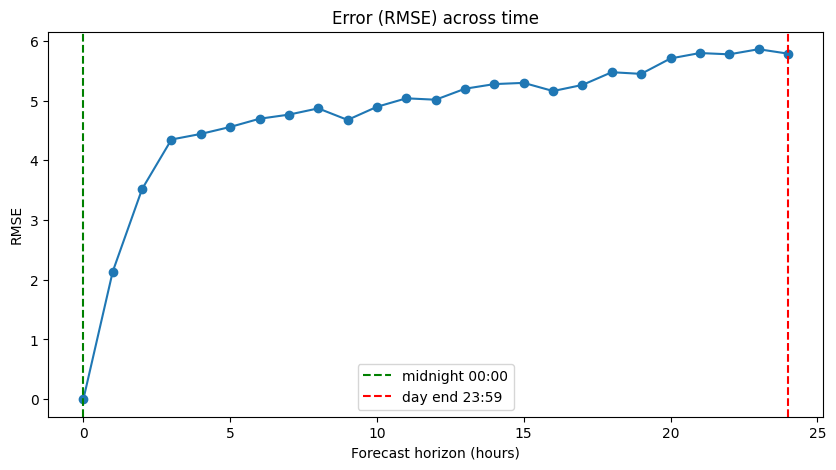

In [ ]:
import matplotlib.pyplot as plt

sf, sfp = sample_future, sample_future_pred
# Calcul du RMSE pour chaque horizon
horizon_rmse = [0] + [
    np.sqrt(np.mean((sf[:, :, horizon] - sfp[:, :, median, horizon])**2))
    for horizon in range(prediction_length)
]

# Plot
plt.figure(figsize=(10,5))
plt.plot(horizon_rmse, marker='o')
plt.title("Error (RMSE) across time")
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("RMSE")

# Repères : début et fin de journée
plt.axvline(0, color='green', linestyle='--', label="midnight 00:00")
plt.axvline(24, color='red', linestyle='--', label="day end 23:59")
plt.legend()
plt.show()